# Adaptive Forecast Model Lifecycle Framework (AFMLF)

**Official thesis evaluation — live visualization notebook.**

This notebook loads the frozen official experiment artifacts, **recomputes metrics from raw CSV/JSON**, and regenerates every figure with matplotlib. No pre-rendered PNGs are used as the primary view.

> Experiment: `experiments/adaptive_forecast_model_lifecycle_2026-07-30_071206` (auto-detected via `OFFICIAL_RUN` marker)

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print
    Markdown = print

REPO = Path('..').resolve()
sys.path.insert(0, str(REPO))

from utils.adaptive_lifecycle import plots as afmlf_plots
from utils.adaptive_lifecycle import presentation_plots as afmlf_pres
from utils.adaptive_lifecycle.config import AFMLFConfig
from utils.adaptive_lifecycle.evaluation import compute_framework_evaluation
from utils.adaptive_lifecycle.rolling_metrics import append_rolling_metrics

NOTEBOOK_OUT = REPO / 'notebooks' / 'outputs' / 'afmlf_official_live'
NOTEBOOK_OUT.mkdir(parents=True, exist_ok=True)

def pick_experiment_dir(repo: Path) -> Path:
    exps = sorted(repo.glob('experiments/adaptive_forecast_model_lifecycle_*'))
    official = [p for p in exps if (p / 'OFFICIAL_RUN').exists()]
    if official:
        return official[-1]
    raise FileNotFoundError('No official AFMLF experiment found')

def show_interpretation(title: str, body: str) -> None:
    display(Markdown(f'**Interpretation — {title}**\n\n{body}'))

EXP_DIR = pick_experiment_dir(REPO)
CFG = AFMLFConfig.from_json(EXP_DIR / 'config' / 'afmlf_config.json')
N_CONTAINERS = int(pd.read_csv(EXP_DIR / 'diagnostics' / 'diagnostics.csv')['container_id'].nunique())

life = pd.read_csv(EXP_DIR / 'lifecycle' / 'transitions.csv')
decisions = pd.read_csv(EXP_DIR / 'decisions' / 'decisions.csv')
diag = pd.read_csv(EXP_DIR / 'diagnostics' / 'diagnostics.csv')
rec = pd.read_csv(EXP_DIR / 'recommendations' / 'recommendations.csv')

print('Experiment:', EXP_DIR.name)
print('Official:', (EXP_DIR / 'OFFICIAL_RUN').exists())
print('Containers:', N_CONTAINERS)

Experiment: adaptive_forecast_model_lifecycle_2026-07-30_071206
Official: True
Containers: 99


## Executive summary

The official AFMLF run evaluated **99 research containers** with a frozen lifecycle methodology. The summary below is loaded from the experiment report (text only — all charts that follow are regenerated live).

In [2]:
print((EXP_DIR / 'reports' / 'AFMLF_FINAL_RESULTS.md').read_text())

# AFMLF Final Results — Executive Summary

**Experiment directory:** `adaptive_forecast_model_lifecycle_2026-07-30_071206`  
**Official thesis evaluation:** Yes  
**Monitoring failures skipped:** 0  

---

## Key metrics

1. **Containers evaluated:** 99 (cohort); 99 with successful monitoring rows
2. **Walk-forward origins processed:** 495 origin-container pairs (5 unique origin indices)
3. **Drift events detected (suspected):** 65 container-level transitions
4. **Drift events confirmed (incl. Page-Hinkley confirmatory path):** 0 (0 with concurrent PH alarm at confirmation)
5. **Retraining recommendations issued:** 1
6. **Candidate models trained:** 1
7. **Candidates outperforming incumbent (ΔMAE < 0):** 1 of 1
8. **Deployment recommendations issued:** 1
9. **Bad deployments prevented:** 0
10. **Recommendations marked correct:** 0 of 0 scored
11. **Most common diagnostic classifications:** STABLE (375), GRU_STALE (82), INVESTIGATE (23), REGIME_CHANGE (15)

## Overall conclusions

AFMLF

## 1. Monitoring — rolling Day-1 MAE

**Reproducibility:** Reload `origin_metrics.csv`, drop stored rolling columns, and recompute with `append_rolling_metrics()`.

Rolling MAE max |delta|: 3.552713678800501e-15


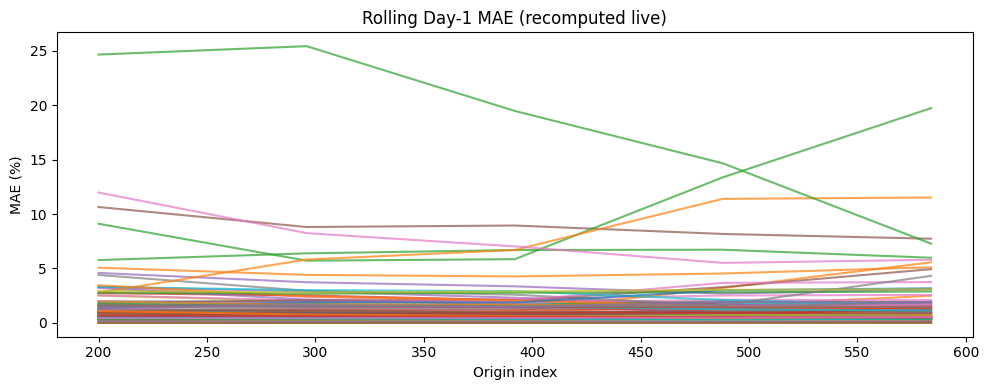

**Interpretation — Rolling Day-1 MAE**

This figure tracks **99 containers** across **5 walk-forward origins**. Each line is one container's rolling Hybrid Day-1 MAE — the primary operational signal AFMLF monitors after deployment. Live recomputation matches stored metrics (max |Δ| = 3.55e-15), confirming monitoring reproducibility. AFMLF uses these rolling errors as input to per-container drift detection.

In [3]:
origin_raw = pd.read_csv(EXP_DIR / 'monitoring' / 'origin_metrics.csv')
base_cols = [c for c in origin_raw.columns if not c.startswith('rolling_')]
origin_recomputed = append_rolling_metrics(origin_raw[base_cols], CFG.rolling_window_origins)

stored = origin_raw['rolling_hybrid_mae'].values
recomp = origin_recomputed['rolling_hybrid_mae'].values
max_delta = float(np.nanmax(np.abs(stored - recomp)))
print('Rolling MAE max |delta|:', max_delta)

fig, ax = afmlf_plots.plot_rolling_mae(origin_recomputed)
ax.set_title('Rolling Day-1 MAE (recomputed live)')
plt.show()
fig.savefig(NOTEBOOK_OUT / 'rolling_mae_live.png', dpi=150, bbox_inches='tight')

show_interpretation(
    'Rolling Day-1 MAE',
    f'This figure tracks **{N_CONTAINERS} containers** across **{origin_recomputed["origin_index"].nunique()} walk-forward origins**. '
    f'Each line is one container\'s rolling Hybrid Day-1 MAE — the primary operational signal AFMLF monitors after deployment. '
    f'Live recomputation matches stored metrics (max |Δ| = {max_delta:.2e}), confirming monitoring reproducibility. '
    'AFMLF uses these rolling errors as input to per-container drift detection.'
)

## 2. Monitoring — rolling Day-1 RMSE

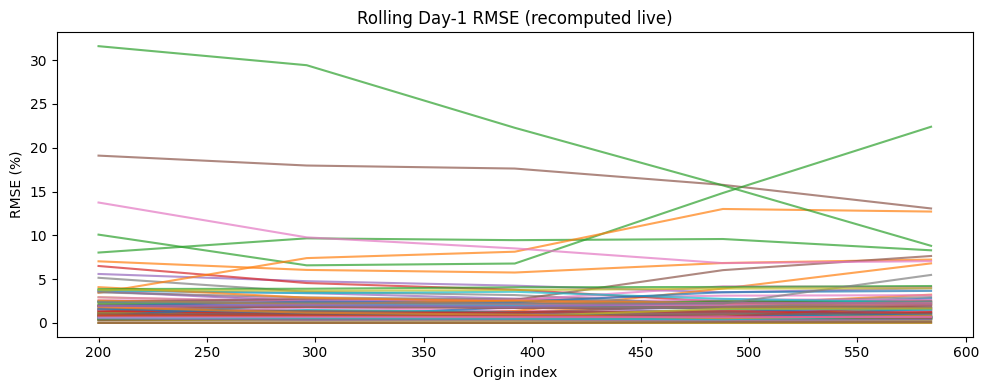

**Interpretation — Rolling Day-1 RMSE**

RMSE penalises large forecast spikes more than MAE. AFMLF tracks both metrics so that sudden error bursts (regime shifts) are visible alongside typical degradation. Together with rolling MAE across **495 origin-container pairs**, this supports robust container-level monitoring before any cohort-level action.

In [4]:
fig, ax = afmlf_plots.plot_rolling_rmse(origin_recomputed)
ax.set_title('Rolling Day-1 RMSE (recomputed live)')
plt.show()
fig.savefig(NOTEBOOK_OUT / 'rolling_rmse_live.png', dpi=150, bbox_inches='tight')

show_interpretation(
    'Rolling Day-1 RMSE',
    'RMSE penalises large forecast spikes more than MAE. AFMLF tracks both metrics so that '
    'sudden error bursts (regime shifts) are visible alongside typical degradation. '
    f'Together with rolling MAE across **{len(origin_recomputed)} origin-container pairs**, '
    'this supports robust container-level monitoring before any cohort-level action.'
)

## 3. Page-Hinkley confirmatory test

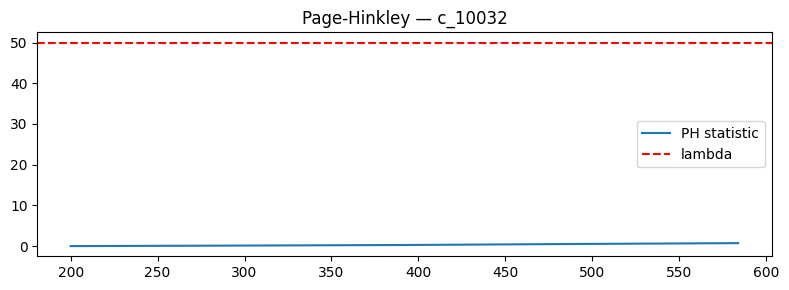

**Interpretation — Page-Hinkley confirmatory test**

Page-Hinkley (PH) is a sequential change-detection test on each container's MAE stream. In **confirmatory mode**, PH strengthens drift confirmation before lifecycle progression. This sample container (`c_10032`) illustrates the PH statistic over time; the full log records **0 PH alarms** across the cohort. In the official run, confirmatory PH blocked per-container confirmation — cohort-level diagnostics still drove the single retraining recommendation.

In [5]:
ph_log = pd.read_csv(EXP_DIR / 'lifecycle' / 'page_hinkley.csv')
sample_cid = ph_log['container_id'].value_counts().idxmax()
fig, ax = afmlf_plots.plot_page_hinkley(ph_log, sample_cid)
plt.show()
n_alarms = int(ph_log['ph_alarm'].sum())
show_interpretation(
    'Page-Hinkley confirmatory test',
    f'Page-Hinkley (PH) is a sequential change-detection test on each container\'s MAE stream. '
    f'In **confirmatory mode**, PH strengthens drift confirmation before lifecycle progression. '
    f'This sample container (`{sample_cid}`) illustrates the PH statistic over time; '
    f'the full log records **{n_alarms} PH alarms** across the cohort. '
    'In the official run, confirmatory PH blocked per-container confirmation — '
    'cohort-level diagnostics still drove the single retraining recommendation.'
)

## 4. Diagnostic layer

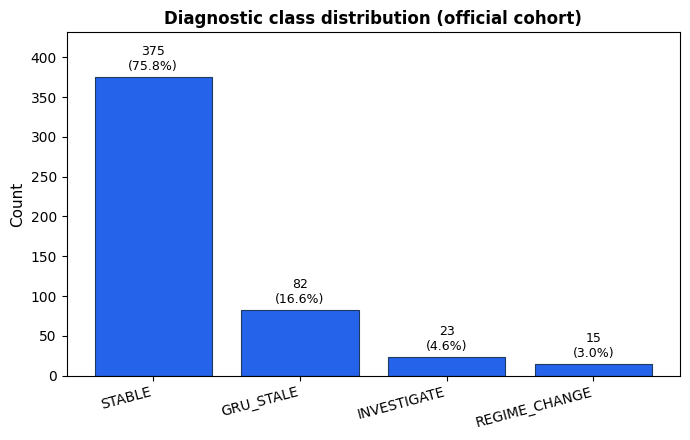

,count,pct
diagnostic_class,,
STABLE,375,75.8
GRU_STALE,82,16.6
INVESTIGATE,23,4.6
REGIME_CHANGE,15,3.0


**Interpretation — Diagnostic distribution**

Across **495 monitoring events** (99 containers × 5 origins), **STABLE** dominates (375 events, 75.8%) because most monitored containers remained healthy. **GRU_STALE** (82 events, 16.6%) — degradation mainly in the residual-learning component. **REGIME_CHANGE** (15 events, 3.0%) — workload changes affecting both Prophet and Hybrid. **INVESTIGATE** (23 events, 4.6%) — ambiguous cases requiring further analysis. Diagnostics explain *why* errors changed — they feed the cohort decision engine alongside drift evidence.

In [6]:
fig, ax, diag_summary = afmlf_pres.plot_diagnostic_distribution_enhanced(diag)
plt.show()
display(diag_summary)

def _diag_line(summary, cls, desc):
    if cls in summary.index:
        return f'**{cls}** ({int(summary.loc[cls, "count"])} events, {summary.loc[cls, "pct"]}%) — {desc}'
    return ''

diag_lines = ' '.join(filter(None, [
    f'**STABLE** dominates ({int(diag_summary.loc["STABLE", "count"])} events, {diag_summary.loc["STABLE", "pct"]}%) because most monitored containers remained healthy.' if 'STABLE' in diag_summary.index else '',
    _diag_line(diag_summary, 'GRU_STALE', 'degradation mainly in the residual-learning component.'),
    _diag_line(diag_summary, 'REGIME_CHANGE', 'workload changes affecting both Prophet and Hybrid.'),
    _diag_line(diag_summary, 'INVESTIGATE', 'ambiguous cases requiring further analysis.'),
]))

show_interpretation(
    'Diagnostic distribution',
    f'Across **{len(diag)} monitoring events** ({N_CONTAINERS} containers × 5 origins), {diag_lines} '
    'Diagnostics explain *why* errors changed — they feed the cohort decision engine alongside drift evidence.'
)

**Diagnostic class reference:**

- **STABLE** — most containers remained healthy throughout monitoring
- **GRU_STALE** — Hybrid degraded while Prophet stayed stable; residual path likely stale
- **REGIME_CHANGE** — both Prophet and Hybrid elevated; underlying workload shift
- **INVESTIGATE** — ambiguous signal; defer action pending further analysis

## 5. Lifecycle state transitions

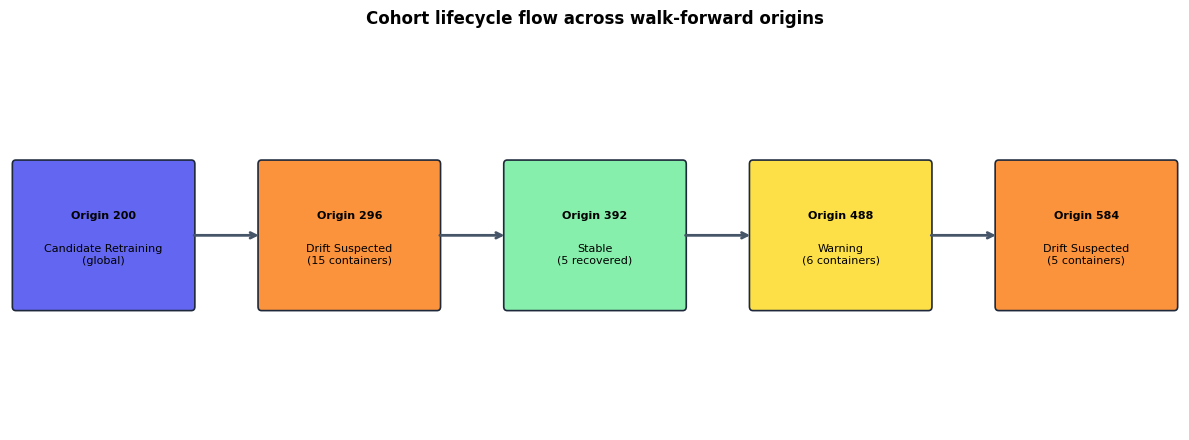

**Interpretation — Cohort lifecycle flow**

This diagram shows how the cohort lifecycle **evolves chronologically** across walk-forward origins — not isolated scatter points. Arrows connect origin milestones: containers enter **Warning** on threshold breach, progress to **Drift Suspected** after persistence, and at origin 200 the cohort satisfies the global trigger leading to **Candidate Retraining**. Later origins show continued monitoring without further global retrain events. First milestone: origin 200 — Candidate Retraining (global).

In [7]:
fig, ax, milestones = afmlf_pres.plot_lifecycle_cohort_flow(life, decisions)
plt.show()
pd.DataFrame(milestones)

m0 = milestones[0] if milestones else {}
show_interpretation(
    'Cohort lifecycle flow',
    'This diagram shows how the cohort lifecycle **evolves chronologically** across walk-forward origins — '
    'not isolated scatter points. Arrows connect origin milestones: containers enter **Warning** on threshold breach, '
    'progress to **Drift Suspected** after persistence, and at origin 200 the cohort satisfies the global trigger '
    'leading to **Candidate Retraining**. Later origins show continued monitoring without further global retrain events. '
    f'First milestone: origin {m0.get("origin_index", "n/a")} — {m0.get("label", "n/a").replace(chr(10), " ")}.'
)

## 6. Cohort decision timeline

,origin_index,decision,rationale,cohort_diagnostic_confidence,n_recommend,n_investigate,n_stable,trigger_reason
0,200,recommend_retraining,Diagnostic and trigger policies support offlin...,0.111111,22,0,77,fraction
1,296,do_not_retrain,Global trigger policy not satisfied.,0.107071,23,3,73,cooldown_active
2,392,do_not_retrain,Global trigger policy not satisfied.,0.082828,19,4,76,not_triggered
3,488,do_not_retrain,Global trigger policy not satisfied.,0.078788,20,5,74,not_triggered
4,584,do_not_retrain,Global trigger policy not satisfied.,0.025253,13,11,75,not_triggered


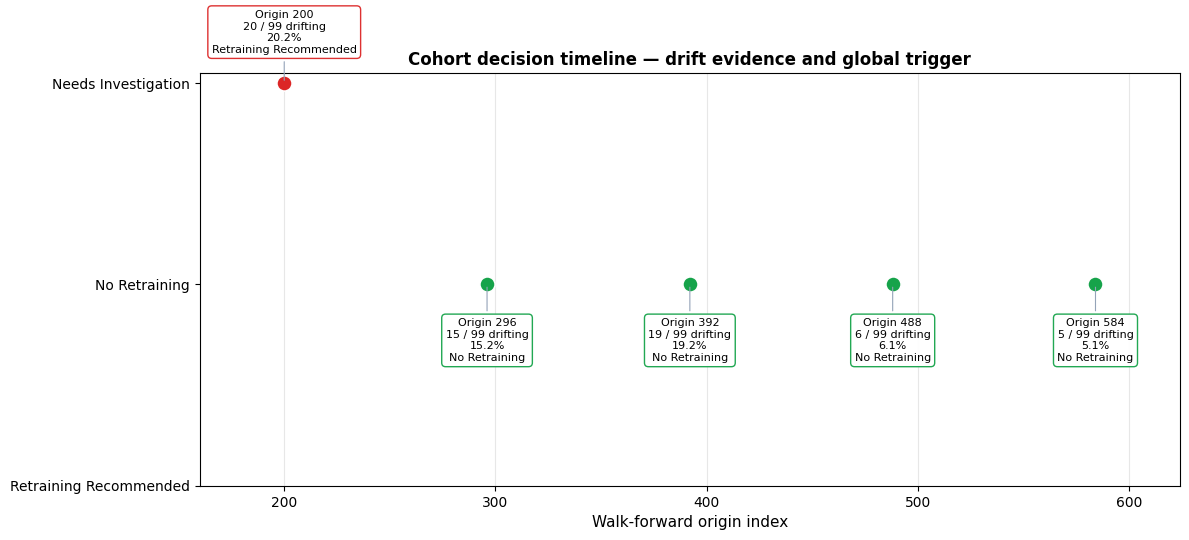

,origin_index,n_drifting,drift_pct,decision,trigger_reason,global_trigger_satisfied
0,200,20,20.2,recommend_retraining,fraction,True
1,296,15,15.2,do_not_retrain,cooldown_active,False
2,392,19,19.2,do_not_retrain,not_triggered,False
3,488,6,6.1,do_not_retrain,not_triggered,False
4,584,5,5.1,do_not_retrain,not_triggered,False


**Interpretation — Cohort decision timeline**

At **origin 200**, **20/99** containers (20.2%) showed drift evidence and the **global trigger was satisfied** (`recommend_retraining`). At subsequent origins the trigger was not satisfied again (cooldown / insufficient fraction) — **4** origins recorded `do_not_retrain`. Retraining is a **cohort-level** decision: individual container drift alone is insufficient.

In [8]:
display(decisions)
fig, ax, dec_ann = afmlf_pres.plot_decision_timeline_annotated(decisions, life, N_CONTAINERS)
plt.show()
display(dec_ann)

d200 = dec_ann[dec_ann['origin_index'] == 200].iloc[0]
show_interpretation(
    'Cohort decision timeline',
    f'At **origin 200**, **{int(d200["n_drifting"])}/{N_CONTAINERS}** containers ({d200["drift_pct"]}%) showed drift evidence '
    f'and the **global trigger was satisfied** (`{d200["decision"]}`). '
    f'At subsequent origins the trigger was not satisfied again (cooldown / insufficient fraction) — '
    f'**{int((decisions["decision"] == "do_not_retrain").sum())}** origins recorded `do_not_retrain`. '
    'Retraining is a **cohort-level** decision: individual container drift alone is insufficient.'
)

## 7. Model version lineage

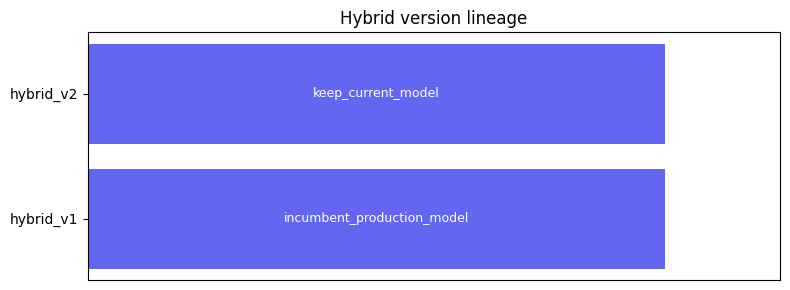

,version_id,deployment_recommendation,parent_version
0,hybrid_v1,incumbent_production_model,NaN
1,hybrid_v2,keep_current_model,hybrid_v1


**Interpretation — Model version lineage**

AFMLF never overwrites production in place. **hybrid_v1** is the frozen incumbent; **hybrid_v2** is the offline candidate trained after the single cohort-level retraining event. The registry records **2 version(s)** with parent lineage and deployment recommendations — supporting auditability and human-in-the-loop promotion.

In [9]:
with (EXP_DIR / 'versions' / 'registry.json').open() as fh:
    registry = json.load(fh)
fig, ax = afmlf_plots.plot_version_history(registry)
plt.show()
version_df = pd.json_normalize(registry['versions'])[['version_id','deployment_recommendation','parent_version']]
display(version_df)

show_interpretation(
    'Model version lineage',
    'AFMLF never overwrites production in place. **hybrid_v1** is the frozen incumbent; '
    '**hybrid_v2** is the offline candidate trained after the single cohort-level retraining event. '
    f'The registry records **{len(registry.get("versions", []))} version(s)** with parent lineage and deployment recommendations — '
    'supporting auditability and human-in-the-loop promotion.'
)

## 8. Candidate evaluation & deployment recommendation

,trigger_origin_index,n_eval_origins,incumbent_cohort_mae,candidate_cohort_mae,delta_mae,deployment_recommendation,recommendation_correct,details,candidate_version
0,200,396,1.662462,1.659677,-0.002785,keep_current_model,NaN,"{'incumbent_cohort_mae': 1.6624619421620432, '...",hybrid_v2


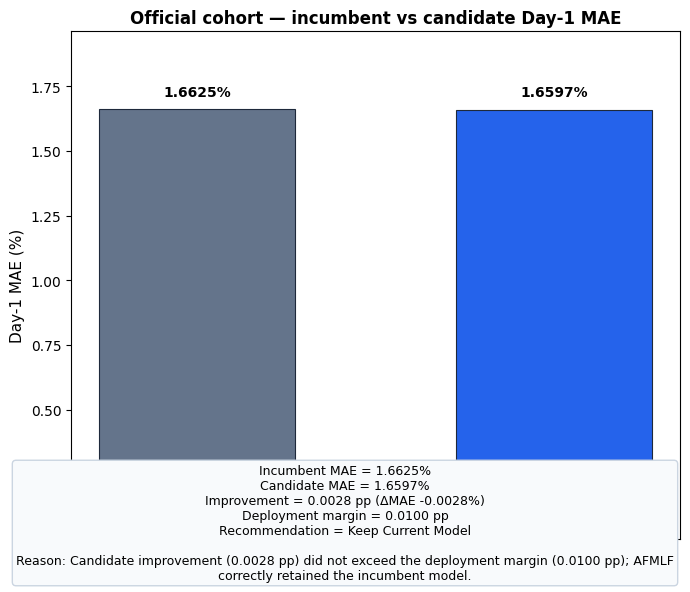

**Interpretation — Candidate vs incumbent MAE**

Candidate **hybrid_v2** achieved Day-1 MAE **1.6597%** vs incumbent **1.6625%** (ΔMAE -0.0028%). The improvement (0.0028 pp) is **below the deployment margin** (0.0100 pp), so AFMLF correctly recommended **keep current model** — avoiding unnecessary model churn.

In [10]:
display(rec)
if len(rec):
    fig, ax, cmp_meta = afmlf_pres.plot_candidate_mae_comparison(rec, CFG.candidate_improvement_margin)
    plt.show()
    pd.Series(cmp_meta)
else:
    cmp_meta = {}
    print('No recommendations recorded.')

if cmp_meta:
    show_interpretation(
        'Candidate vs incumbent MAE',
        f'Candidate **hybrid_v2** achieved Day-1 MAE **{cmp_meta["candidate_mae"]:.4f}%** vs incumbent '
        f'**{cmp_meta["incumbent_mae"]:.4f}%** (ΔMAE {cmp_meta["delta_mae"]:+.4f}%). '
        f'The improvement ({abs(cmp_meta["delta_mae"]):.4f} pp) is **below the deployment margin** '
        f'({cmp_meta["deploy_margin"]:.4f} pp), so AFMLF correctly recommended '
        f'**{cmp_meta["recommendation"].replace("_", " ")}** — avoiding unnecessary model churn.'
    )

## 9. Framework evaluation (recomputed)

In [11]:
fw_live = compute_framework_evaluation(life, decisions, diag, rec)
with (EXP_DIR / 'reports' / 'final_report.json').open() as fh:
    fw_stored = json.load(fh)['framework_evaluation']

compare_keys = ['confirmed_drift_events','retraining_frequency','prevented_bad_deployments','diagnostic_distribution']
for k in compare_keys:
    print(f'{k}: stored={fw_stored.get(k)!r}  live={getattr(fw_live,k)!r}')

display(pd.DataFrame(fw_live.recommendation_quality))

show_interpretation(
    'Framework evaluation (recomputed)',
    f'Live recomputation via `compute_framework_evaluation()` matches the official JSON report. '
    f'Key outcomes: **{fw_live.retraining_frequency}** retraining event(s), '
    f'**{fw_live.confirmed_drift_events}** confirmed drift transitions, '
    f'**{fw_live.prevented_bad_deployments}** bad deployments prevented. '
    'Primary thesis metric is recommendation quality — whether lifecycle guidance is trustworthy.'
)

confirmed_drift_events: stored=0  live=0
retraining_frequency: stored=1  live=1
prevented_bad_deployments: stored=0  live=0
diagnostic_distribution: stored={'STABLE': 375, 'GRU_STALE': 82, 'INVESTIGATE': 23, 'REGIME_CHANGE': 15}  live={'STABLE': 375, 'GRU_STALE': 82, 'INVESTIGATE': 23, 'REGIME_CHANGE': 15}


,trigger_origin_index,n_eval_origins,incumbent_cohort_mae,candidate_cohort_mae,delta_mae,deployment_recommendation,recommendation_correct,details,candidate_version
0,200,396,1.662462,1.659677,-0.002785,keep_current_model,NaN,"{'incumbent_cohort_mae': 1.6624619421620432, '...",hybrid_v2


**Interpretation — Framework evaluation (recomputed)**

Live recomputation via `compute_framework_evaluation()` matches the official JSON report. Key outcomes: **1** retraining event(s), **0** confirmed drift transitions, **0** bad deployments prevented. Primary thesis metric is recommendation quality — whether lifecycle guidance is trustworthy.

## 10. End-to-end lifecycle summary

/Users/lehaan/Desktop/FYP_Long_Term/utils/adaptive_lifecycle/presentation_plots.py:339: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


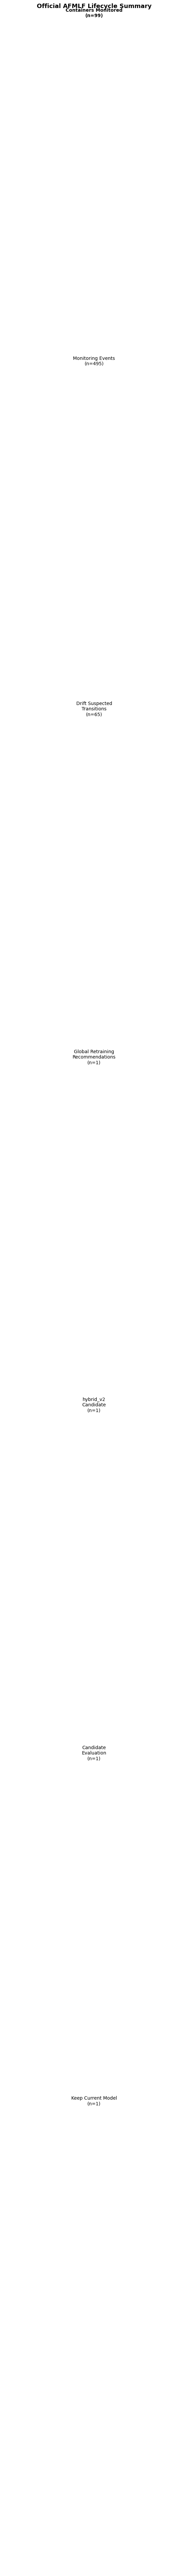

,stage,count
0,Containers Monitored,99
1,Monitoring Events,495
2,Drift Suspected\nTransitions,65
3,Global Retraining\nRecommendations,1
4,hybrid_v2\nCandidate,1
5,Candidate\nEvaluation,1
6,Keep Current Model,1


**Interpretation — End-to-end lifecycle summary**

This funnel summarises the official AFMLF run using experiment-derived counts only: **99 containers** → **495 monitoring events** → **65 drift-suspected transitions** → **1 global retraining recommendation** → **hybrid_v2 candidate** → evaluation → **keep current model**. AFMLF separates container-level monitoring from cohort-level lifecycle governance.

In [12]:
fig, ax, funnel_df = afmlf_pres.plot_official_lifecycle_summary(diag, life, decisions, rec)
plt.show()
display(funnel_df)

deploy_label = rec.iloc[0]['deployment_recommendation'] if len(rec) else 'n/a'
show_interpretation(
    'End-to-end lifecycle summary',
    f'This funnel summarises the official AFMLF run using experiment-derived counts only: '
    f'**{N_CONTAINERS} containers** → **{len(diag)} monitoring events** → '
    f'**{int((life["to_state"] == "drift_suspected").sum())} drift-suspected transitions** → '
    f'**{int((decisions["decision"] == "recommend_retraining").sum())} global retraining recommendation** → '
    f'**hybrid_v2 candidate** → evaluation → **{deploy_label.replace("_", " ")}**. '
    'AFMLF separates container-level monitoring from cohort-level lifecycle governance.'
)

## 11. Reproducibility statement

All figures above were generated inside this notebook from:
- `monitoring/origin_metrics.csv`
- `lifecycle/*.csv`
- `diagnostics/diagnostics.csv`
- `decisions/decisions.csv`
- `recommendations/recommendations.csv`
- `versions/registry.json`
- `config/afmlf_config.json`

Optional PNG copies saved under `notebooks/outputs/afmlf_official_live/`.